# FINANCE 710

## Lecture 1: Python Basics for Finance

This notebook introduces the Python knowledge needed to begin FINANCE 710 empirical work: variables, lists, dictionaries, functions, pandas DataFrames, NumPy arrays, plots, and simple finance calculations.



## Learning objectives

After completing this notebook, you should be able to:

1. run Python code cells and interpret simple output;
2. create and reuse variables;
3. work with lists, dictionaries, and functions;
4. create a small pandas DataFrame;
5. calculate returns and excess returns;
6. summarize and plot a small financial dataset;
7. identify targets, features, and timing in a basic prediction task.


## 1. A first Python instruction

Run the next cell. Then edit the message and run it again.


In [1]:
print("Hello, FINANCE 710")


Hello, FINANCE 710


## 2. Variables: names that point to values

A variable lets us store a value and use it later. This is the basic unit of reproducible analysis: instead of typing the same number repeatedly, we name the quantity once.


In [2]:
monthly_return = 0.012
risk_free_rate = 0.003

excess_return = monthly_return - risk_free_rate

print(excess_return)


0.009000000000000001


## 3. Common Python data types

Python objects have types. The type determines what operations make sense.


In [3]:
price = 101.25                 # float
shares = 200                   # integer
ticker = "AAPL"                # string
is_large_cap = True            # Boolean

print(type(price))
print(type(shares))
print(type(ticker))
print(type(is_large_cap))


<class 'float'>
<class 'int'>
<class 'str'>
<class 'bool'>


## 4. Lists and dictionaries

A list stores ordered values. A dictionary stores values by key.


In [4]:
returns = [0.012, -0.008, 0.020]
print("First return:", returns[0])
print("Number of returns:", len(returns))

stock = {"ticker": "ABC", "sector": "Banking", "market_cap_millions": 2500}
print(stock["ticker"])
print(stock["market_cap_millions"])


First return: 0.012
Number of returns: 3
ABC
2500


Python starts counting at zero, so `returns[0]` is the first element.


## 5. Functions: reusable calculations

A function collects a calculation under one name. This is useful when the same calculation must be applied consistently.


In [5]:
def calculate_excess_return(asset_return, risk_free_rate):
    return asset_return - risk_free_rate

calculate_excess_return(0.012, 0.003)


0.009000000000000001

In [6]:
example_returns = [0.012, -0.008, 0.020]
risk_free_rate = 0.003

for r in example_returns:
    print(calculate_excess_return(r, risk_free_rate))


0.009000000000000001
-0.011
0.017


## 6. Importing finance data packages

Packages extend Python. FINANCE 710 will mainly use:

- `pandas` for tables;
- `numpy` for numerical arrays;
- `matplotlib` for plots.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Packages imported.")


Packages imported.


## 7. A small financial dataset

The next cell creates a small table of monthly prices for two hypothetical assets. We create the data inside the notebook so the first exercise does not depend on external files.


In [8]:
prices = pd.DataFrame(
    {
        "Auckland_Bank": [100.00, 101.20, 100.40, 102.50, 103.10, 104.30],
        "Harbour_Tech": [50.00, 52.50, 51.00, 54.20, 53.80, 56.10],
    },
    index=pd.to_datetime(
        ["2026-01-31", "2026-02-28", "2026-03-31",
         "2026-04-30", "2026-05-31", "2026-06-30"]
    ),
)

prices


,Auckland_Bank,Harbour_Tech
2026-01-31,100.0,50.0
2026-02-28,101.2,52.5
2026-03-31,100.4,51.0
2026-04-30,102.5,54.2
2026-05-31,103.1,53.8
2026-06-30,104.3,56.1


In [9]:
prices.head()


,Auckland_Bank,Harbour_Tech
2026-01-31,100.0,50.0
2026-02-28,101.2,52.5
2026-03-31,100.4,51.0
2026-04-30,102.5,54.2
2026-05-31,103.1,53.8


In [10]:
prices.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6 entries, 2026-01-31 to 2026-06-30
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Auckland_Bank  6 non-null      float64
 1   Harbour_Tech   6 non-null      float64
dtypes: float64(2)
memory usage: 144.0 bytes


## 8. Prices to returns

For a simple return:

$r_t = \frac{P_t}{P_{t-1}} - 1.$

pandas can compute this with `pct_change()`.


In [11]:
returns = prices.pct_change()
returns


,Auckland_Bank,Harbour_Tech
2026-01-31,NaN,NaN
2026-02-28,0.012000,0.050000
2026-03-31,-0.007905,-0.028571
2026-04-30,0.020916,0.062745
2026-05-31,0.005854,-0.007380
2026-06-30,0.011639,0.042751


The first row is missing because there is no previous price. For most analysis we remove it after checking that the missing value is expected.


In [12]:
returns = returns.dropna()
returns


,Auckland_Bank,Harbour_Tech
2026-02-28,0.012000,0.050000
2026-03-31,-0.007905,-0.028571
2026-04-30,0.020916,0.062745
2026-05-31,0.005854,-0.007380
2026-06-30,0.011639,0.042751


## 9. Excess returns

If the monthly risk-free rate is 0.3 percent, the excess return is:

$r^e_t = r_t - r_{f,t}.$


In [13]:
risk_free_rate = 0.003
excess_returns = returns - risk_free_rate
excess_returns


,Auckland_Bank,Harbour_Tech
2026-02-28,0.009000,0.047000
2026-03-31,-0.010905,-0.031571
2026-04-30,0.017916,0.059745
2026-05-31,0.002854,-0.010380
2026-06-30,0.008639,0.039751


## 10. Summary statistics

Summary statistics are not a substitute for modelling, but they are a useful first diagnostic.


In [14]:
summary = pd.DataFrame({
    "mean_monthly_excess_return": excess_returns.mean(),
    "volatility": excess_returns.std(),
    "minimum": excess_returns.min(),
    "maximum": excess_returns.max(),
})

summary


,mean_monthly_excess_return,volatility,minimum,maximum
Auckland_Bank,0.005501,0.010635,-0.010905,0.017916
Harbour_Tech,0.020909,0.039614,-0.031571,0.059745


In [15]:
summary["mean_to_volatility"] = (
    summary["mean_monthly_excess_return"] / summary["volatility"]
)

summary


,mean_monthly_excess_return,volatility,minimum,maximum,mean_to_volatility
Auckland_Bank,0.005501,0.010635,-0.010905,0.017916,0.517243
Harbour_Tech,0.020909,0.039614,-0.031571,0.059745,0.527811


## 11. A simple plot

Plots help detect patterns and mistakes. Here we plot cumulative growth from the two price series.


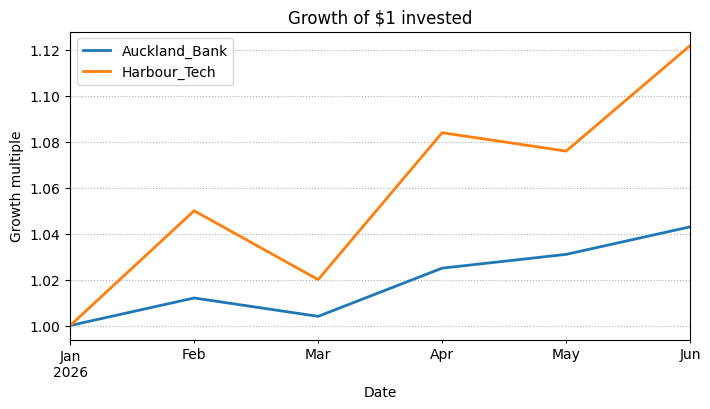

In [16]:
growth = prices / prices.iloc[0]

ax = growth.plot(figsize=(8, 4), linewidth=2)
ax.set_title("Growth of $1 invested")
ax.set_ylabel("Growth multiple")
ax.set_xlabel("Date")
ax.grid(True, linestyle=":")
plt.show()


## 12. Features, targets, and timing

Suppose the decision is to forecast next month's return for a single asset, using only information available at the end of this month. This month's return can be a feature; next month's return is the target.

We keep to one asset here so the timing is easy to see. With many assets in one table, the same steps are repeated within each asset, which we cover next week.

In [17]:
# One asset, kept as an ordered monthly time series (one row per month).
one_asset = returns[["Auckland_Bank"]].rename(columns={"Auckland_Bank": "return"})

# Target: next month's return. shift(-1) pulls the future value back onto this row.
one_asset["next_month_return"] = one_asset["return"].shift(-1)

one_asset

,return,next_month_return
2026-02-28,0.012000,-0.007905
2026-03-31,-0.007905,0.020916
2026-04-30,0.020916,0.005854
2026-05-31,0.005854,0.011639
2026-06-30,0.011639,NaN


The row dated February contains information known at the end of February. The `next_month_return` column is the future outcome. It is a target, not a feature.


In [18]:
model_data = one_asset.dropna(subset=["next_month_return"]).copy()

features = ["return"]
target = "next_month_return"

model_data[features + [target]]

,return,next_month_return
2026-02-28,0.012000,-0.007905
2026-03-31,-0.007905,0.020916
2026-04-30,0.020916,0.005854
2026-05-31,0.005854,0.011639


## 13. Clean runtime check

Before relying on a notebook:

1. restart the kernel/runtime;
2. run all cells from top to bottom;
3. confirm that every output is recreated by code;
4. confirm that the target is not accidentally used as a feature.